In [1]:
print("Hello")

Hello


In [2]:
import pandas as pd

print(pd.__version__)

3.0.3


In [3]:
import pandas as pd

clients = pd.read_csv("../data/clients.csv")
properties = pd.read_csv("../data/properties.csv")

print("Clients Shape:", clients.shape)
print("Properties Shape:", properties.shape)

Clients Shape: (2000, 12)
Properties Shape: (10000, 9)


In [4]:
clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [5]:
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   client_id            2000 non-null   str  
 1   client_type          2000 non-null   str  
 2   first_name           2000 non-null   str  
 3   last_name            2000 non-null   str  
 4   date_of_birth        2000 non-null   str  
 5   gender               2000 non-null   str  
 6   country              2000 non-null   str  
 7   region               2000 non-null   str  
 8   acquisition_purpose  2000 non-null   str  
 9   satisfaction_score   2000 non-null   int64
 10  loan_applied         2000 non-null   str  
 11  referral_channel     2000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 312.6 KB


In [6]:
clients.isnull().sum()

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

In [7]:
clients.duplicated().sum()

np.int64(0)

In [8]:
from datetime import datetime

current_year = datetime.now().year

clients['date_of_birth'] = pd.to_datetime(
    clients['date_of_birth'],
    errors='coerce'
)

clients['age'] = current_year - clients['date_of_birth'].dt.year

clients[['date_of_birth','age']].head()

,date_of_birth,age
0,1968-05-11,58.0
1,NaT,NaN
2,1959-04-07,67.0
3,NaT,NaN
4,NaT,NaN


In [9]:
clients_ml = clients.drop(
    columns=[
        'client_id',
        'first_name',
        'last_name'
    ]
)
clients_ml.head()

,client_type,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age
0,Individual,1968-05-11,F,USA,California,Home,4,Yes,Website,58.0
1,Individual,NaT,M,USA,California,Home,1,No,Website,NaN
2,Individual,1959-04-07,M,USA,California,Home,4,Yes,Agency,67.0
3,Individual,NaT,M,USA,California,Home,5,No,Website,NaN
4,Company,NaT,M,USA,California,Investment,5,No,Website,NaN


In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    'client_type',
    'gender',
    'country',
    'region',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel'
]

for col in cat_cols:
    le = LabelEncoder()
    clients_ml[col] = le.fit_transform(clients_ml[col].astype(str))


In [15]:
clients_ml.columns

Index(['client_type', 'date_of_birth', 'gender', 'country', 'region',
       'acquisition_purpose', 'satisfaction_score', 'loan_applied',
       'referral_channel', 'age'],
      dtype='str')

In [16]:
clients_ml = clients_ml.drop(columns=['date_of_birth'])

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
clients_scaled = scaler.fit_transform(clients_ml)

print(clients_scaled.shape)

(2000, 9)


In [21]:
clients_ml['age'] = clients_ml['age'].fillna(
    clients_ml['age'].median()
)

In [22]:
clients_ml.isnull().sum()

client_type            0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
age                    0
dtype: int64

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

clients_scaled = scaler.fit_transform(clients_ml)

In [24]:
import numpy as np

print(np.isnan(clients_scaled).sum())

0


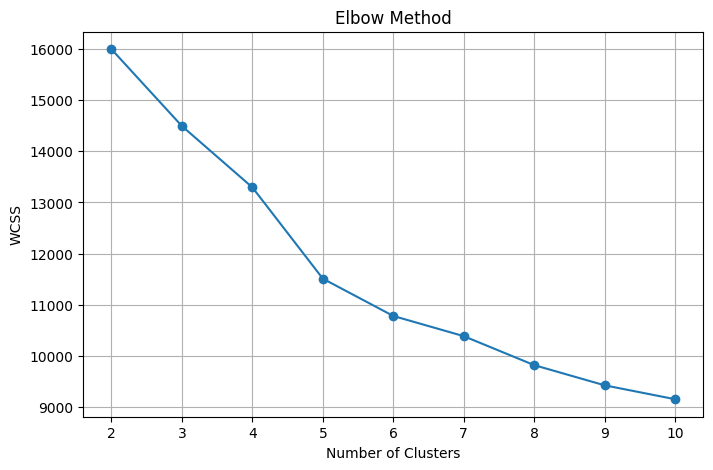

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(clients_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(clients_scaled)

clients['Cluster'] = clusters

clients[['client_type','acquisition_purpose','Cluster']].head()

,client_type,acquisition_purpose,Cluster
0,Individual,Home,3
1,Individual,Home,2
2,Individual,Home,2
3,Individual,Home,2
4,Company,Investment,4


In [27]:
clients['Cluster'].value_counts()

Cluster
3    574
2    566
1    506
0    251
4    103
Name: count, dtype: int64

In [28]:
cluster_summary = clients.groupby('Cluster').agg({
    'satisfaction_score':'mean',
    'age':'mean'
})

cluster_summary

,satisfaction_score,age
Cluster,,
0,3.051793,50.405405
1,3.025692,55.417778
2,3.003534,58.432099
3,3.040070,55.345992
4,3.067961,48.205128


In [29]:
pd.crosstab(
    clients['Cluster'],
    clients['client_type']
)

client_type,Company,Individual
Cluster,,
0,0,251
1,0,506
2,0,566
3,0,574
4,103,0


In [31]:
pd.crosstab(
    clients['Cluster'],
    clients['acquisition_purpose']
)

acquisition_purpose,Home,Investment
Cluster,,
0,178,73
1,0,506
2,566,0
3,574,0
4,67,36


In [33]:
pd.crosstab(
    clients['Cluster'],
    clients['loan_applied']
)

loan_applied,No,Yes
Cluster,,
0,167,84
1,313,193
2,364,202
3,360,214
4,60,43


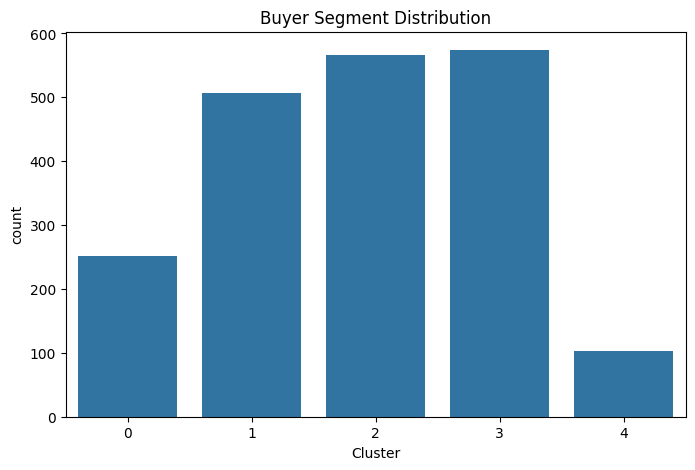

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(
    data=clients,
    x='Cluster'
)

plt.title("Buyer Segment Distribution")
plt.show()

In [35]:
clients['Cluster'].value_counts()

Cluster
3    574
2    566
1    506
0    251
4    103
Name: count, dtype: int64

In [36]:
pd.crosstab(clients['Cluster'], clients['client_type'])

client_type,Company,Individual
Cluster,,
0,0,251
1,0,506
2,0,566
3,0,574
4,103,0


In [37]:
pd.crosstab(clients['Cluster'], clients['acquisition_purpose'])

acquisition_purpose,Home,Investment
Cluster,,
0,178,73
1,0,506
2,566,0
3,574,0
4,67,36


In [38]:
pd.crosstab(
    clients['Cluster'],
    clients['loan_applied']
)

loan_applied,No,Yes
Cluster,,
0,167,84
1,313,193
2,364,202
3,360,214
4,60,43


In [39]:
clients.groupby('Cluster').agg({
    'age':'mean',
    'satisfaction_score':'mean'
}).round(2)

,age,satisfaction_score
Cluster,,
0,50.41,3.05
1,55.42,3.03
2,58.43,3.00
3,55.35,3.04
4,48.21,3.07


In [43]:
segment_names = {
    0: "Local Buyers",
    1: "Global Investors",
    2: "Mature Home Buyers",
    3: "First-Time Buyers",
    4: "Corporate Buyers"
}

clients['Segment'] = clients['Cluster'].map(segment_names)

clients[['Cluster','Segment']].head()

,Cluster,Segment
0,3,First-Time Buyers
1,2,Mature Home Buyers
2,2,Mature Home Buyers
3,2,Mature Home Buyers
4,4,Corporate Buyers


In [44]:
clients.to_csv(
    "../data/clustered_clients.csv",
    index=False
)

print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!
